In [1]:
# General libraries 
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.environ["KERAS_BACKEND"] = "torch"

# Deep learning
from keras.layers import Dense
from keras.models import Sequential
from keras.utils import to_categorical
from keras.optimizers import SGD
from keras.callbacks import EarlyStopping
#from keras.utils import np_utils
import itertools
from keras.layers import LSTM
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Dropout

#sk.learn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\Research\final_cells\cell_13.csv')
df

,time,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
0,00:00,4459.0,NaN,342.0,378.559082,439.907166,0.932356,1.421794,126.568209,45.759521
1,00:03,4557.0,6.590193,330.0,377.143951,433.470703,0.908957,1.409065,119.787053,49.938053
2,00:06,4163.0,4.322272,304.0,376.929626,429.153748,0.893875,1.398350,110.080039,49.350605
3,00:09,4329.0,6.327115,306.0,376.815186,422.827667,0.894242,1.482987,112.150715,50.196867
4,00:12,4652.0,5.710200,322.0,377.667450,417.181427,0.898780,1.500716,117.901765,51.688206
...,...,...,...,...,...,...,...,...,...,...
59,02:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,03:03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,03:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.set_index('time', inplace=True)

In [4]:
df

,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
time,,,,,,,,,
00:00,4459.0,NaN,342.0,378.559082,439.907166,0.932356,1.421794,126.568209,45.759521
00:03,4557.0,6.590193,330.0,377.143951,433.470703,0.908957,1.409065,119.787053,49.938053
00:06,4163.0,4.322272,304.0,376.929626,429.153748,0.893875,1.398350,110.080039,49.350605
00:09,4329.0,6.327115,306.0,376.815186,422.827667,0.894242,1.482987,112.150715,50.196867
00:12,4652.0,5.710200,322.0,377.667450,417.181427,0.898780,1.500716,117.901765,51.688206
...,...,...,...,...,...,...,...,...,...
02:57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
03:03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.corr()

,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
area,1.000000,-0.862031,0.879586,0.054205,0.009600,-0.087639,0.249477,0.321445,0.360492
speed,-0.862031,1.000000,-0.665224,-0.281958,-0.287405,0.034187,-0.321119,-0.287105,-0.215322
perimeter,0.879586,-0.665224,1.000000,-0.245003,-0.269250,0.046784,0.079904,0.425078,0.260629
xcentre,0.054205,-0.281958,-0.245003,1.000000,0.932555,-0.043039,0.047403,0.041963,-0.178019
ycentre,0.009600,-0.287405,-0.269250,0.932555,1.000000,0.182213,0.199680,0.250773,-0.402431
eccentricity,-0.087639,0.034187,0.046784,-0.043039,0.182213,1.000000,-0.023937,0.874716,-0.908146
orientation,0.249477,-0.321119,0.079904,0.047403,0.199680,-0.023937,1.000000,0.119797,-0.039820
major_axis,0.321445,-0.287105,0.425078,0.041963,0.250773,0.874716,0.119797,1.000000,-0.715466
minor_axis,0.360492,-0.215322,0.260629,-0.178019,-0.402431,-0.908146,-0.039820,-0.715466,1.000000


In [6]:
df.area.iloc[60]

nan

In [7]:
df = df[:df.area.isnull().idxmax()]
df

,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
time,,,,,,,,,
00:00,4459.0,NaN,342.0,378.559082,439.907166,0.932356,1.421794,126.568209,45.759521
00:03,4557.0,6.590193,330.0,377.143951,433.470703,0.908957,1.409065,119.787053,49.938053
00:06,4163.0,4.322272,304.0,376.929626,429.153748,0.893875,1.398350,110.080039,49.350605
00:09,4329.0,6.327115,306.0,376.815186,422.827667,0.894242,1.482987,112.150715,50.196867
00:12,4652.0,5.710200,322.0,377.667450,417.181427,0.898780,1.500716,117.901765,51.688206
00:15,4938.0,7.620553,342.0,381.731659,410.735107,0.891614,-1.496453,119.761056,54.227277
00:18,4786.0,7.412550,338.0,379.378387,403.706024,0.844024,-1.544918,108.889729,58.398176
00:21,4732.0,4.447029,338.0,378.525787,399.341492,0.570291,1.185660,88.028693,72.310550
00:24,4655.0,9.998815,324.0,377.520508,389.393341,0.549959,0.906971,84.915008,70.920290


In [8]:
df = df.fillna(df.mean())
df

,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
time,,,,,,,,,
00:00,4459.000000,8.112675,342.000000,378.559082,439.907166,0.932356,1.421794,126.568209,45.759521
00:03,4557.000000,6.590193,330.000000,377.143951,433.470703,0.908957,1.409065,119.787053,49.938053
00:06,4163.000000,4.322272,304.000000,376.929626,429.153748,0.893875,1.398350,110.080039,49.350605
00:09,4329.000000,6.327115,306.000000,376.815186,422.827667,0.894242,1.482987,112.150715,50.196867
00:12,4652.000000,5.710200,322.000000,377.667450,417.181427,0.898780,1.500716,117.901765,51.688206
00:15,4938.000000,7.620553,342.000000,381.731659,410.735107,0.891614,-1.496453,119.761056,54.227277
00:18,4786.000000,7.412550,338.000000,379.378387,403.706024,0.844024,-1.544918,108.889729,58.398176
00:21,4732.000000,4.447029,338.000000,378.525787,399.341492,0.570291,1.185660,88.028693,72.310550
00:24,4655.000000,9.998815,324.000000,377.520508,389.393341,0.549959,0.906971,84.915008,70.920290


In [9]:
df.corr()

,area,speed,perimeter,xcentre,ycentre,eccentricity,orientation,major_axis,minor_axis
area,1.000000,-0.861599,0.879586,0.054205,0.009600,-0.087639,0.249477,0.321445,0.360492
speed,-0.861599,1.000000,-0.664721,-0.275623,-0.266895,0.033390,-0.314800,-0.270574,-0.203553
perimeter,0.879586,-0.664721,1.000000,-0.245003,-0.269250,0.046784,0.079904,0.425078,0.260629
xcentre,0.054205,-0.275623,-0.245003,1.000000,0.932555,-0.043039,0.047403,0.041963,-0.178019
ycentre,0.009600,-0.266895,-0.269250,0.932555,1.000000,0.182213,0.199680,0.250773,-0.402431
eccentricity,-0.087639,0.033390,0.046784,-0.043039,0.182213,1.000000,-0.023937,0.874716,-0.908146
orientation,0.249477,-0.314800,0.079904,0.047403,0.199680,-0.023937,1.000000,0.119797,-0.039820
major_axis,0.321445,-0.270574,0.425078,0.041963,0.250773,0.874716,0.119797,1.000000,-0.715466
minor_axis,0.360492,-0.203553,0.260629,-0.178019,-0.402431,-0.908146,-0.039820,-0.715466,1.000000


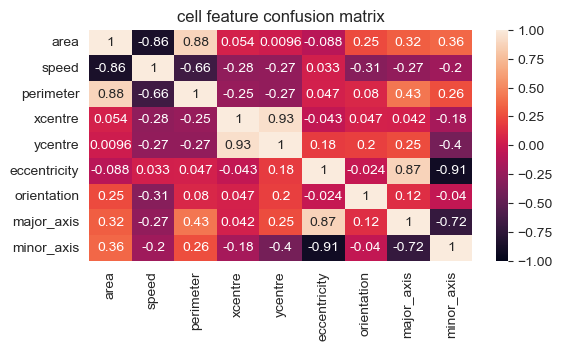

In [10]:
import seaborn as sns
f= plt.figure(figsize=(21,3))

ax=f.add_subplot(133)
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True)
plt.title('cell feature confusion matrix', size=12)
plt.show()

In [ ]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    dff = pd.DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(dff.shift(-i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(dff.shift(-i))
        if i==0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1)) for j in range(n_vars)]
        agg = pd.concat(cols, axis=1)
        agg.columns = names
        if dropnan:
            agg.dropna(inplace=True)
        return agg
    